# Content-Based Movie Recommender


## 1. Imports & Data Loading

In [1]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

movies  = pd.read_csv("data/movies.csv")
credits = pd.read_csv("data/credits.csv")

credits.rename(columns={"movie_id": "id"}, inplace=True)
movies["id"]  = movies["id"].astype(str)
credits["id"] = credits["id"].astype(str)
df = movies.merge(credits, on="id", how="left", suffixes=("", "_c"))

print(f"Shape: {df.shape}")
df[["title","overview","genres","cast","crew"]].head(2)


Shape: (4803, 23)


,title,overview,genres,cast,crew
0,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


## 2. Feature Engineering

In [2]:
def safe_parse(val):
    try:
        return ast.literal_eval(val)
    except Exception:
        return []

def get_names(val, limit=None):
    """Extract names from a JSON-list column, normalised to lowercase no-space."""
    items = safe_parse(val)
    names = [i.get("name","").replace(" ","").lower()
             for i in items if isinstance(i, dict)]
    return names[:limit] if limit else names

def get_director(crew_val):
    """Extract the director's name from crew JSON."""    
    for member in safe_parse(crew_val):
        if isinstance(member, dict) and member.get("job") == "Director":
            return member.get("name","").replace(" ","").lower()
    return ""

df["_genres"]   = df["genres"].apply(get_names)
df["_cast"]     = df["cast"].apply(lambda x: get_names(x, limit=3))
df["_keywords"] = df["keywords"].apply(lambda x: get_names(x, limit=5))
df["_director"] = df["crew"].apply(get_director)
df["overview"]  = df["overview"].fillna("")

# Display-friendly versions (not lowercased)
df["genres_list"] = df["genres"].apply(
    lambda x: [i.get("name","") for i in safe_parse(x)])
df["cast_display"] = df["cast"].apply(
    lambda x: [i.get("name","") for i in safe_parse(x)][:5])
df["director"] = df["crew"].apply(
    lambda x: next((m.get("name","") for m in safe_parse(x)
                    if isinstance(m,dict) and m.get("job")=="Director"), ""))

print("Sample features for:", df["title"].iloc[0])
print("  Genres   :", df["_genres"].iloc[0])
print("  Cast     :", df["_cast"].iloc[0])
print("  Keywords :", df["_keywords"].iloc[0])
print("  Director :", df["_director"].iloc[0])


Sample features for: Avatar
  Genres   : ['action', 'adventure', 'fantasy', 'sciencefiction']
  Cast     : ['samworthington', 'zoesaldana', 'sigourneyweaver']
  Keywords : ['cultureclash', 'future', 'spacewar', 'spacecolony', 'society']
  Director : jamescameron


### Why weighting matters

We repeat high-signal features so TF-IDF assigns them more importance:

| Feature | Repetitions | Reasoning |
|---------|-------------|-----------|
| Overview | ×2 | Rich narrative context |
| Genres | ×2 | Strongest stylistic signal |
| Director | ×2 | Directorial style is very consistent |
| Cast | ×1 | Useful but actors span many genres |
| Keywords | ×1 | Niche but precise |


In [3]:
def build_soup(row):
    parts = []
    overview = row.get("overview","")
    parts += [overview, overview]                  # overview ×2
    parts += row.get("_genres",[]) * 2             # genres ×2
    parts += row.get("_cast",[])[:3]               # top-3 cast ×1
    parts += row.get("_keywords",[])[:5]           # keywords ×1
    director = row.get("_director","")
    if director:
        parts += [director, director]              # director ×2
    return " ".join(parts)

df["soup"] = df.apply(build_soup, axis=1)

# Preview one soup
print("Soup for:", df["title"].iloc[1])
print(df["soup"].iloc[1])


Soup for: Pirates of the Caribbean: At World's End
Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems. Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems. adventure fantasy action adventure fantasy action johnnydepp orlandobloom keiraknightley ocean drugabuse exoticisland eastindiatradingcompany loveofone'slife goreverbinski goreverbinski


## 3. TF-IDF Vectorisation with Bigrams

In [4]:
# ngram_range=(1,2) means single words AND two-word phrases are features
# e.g. "dark", "knight", "dark knight" are all separate features
tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=20000)

tfidf_matrix = tfidf.fit_transform(df["soup"])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} movies × {tfidf_matrix.shape[1]} features")


TF-IDF matrix shape: (4803, 20000)
  → 4803 movies × 20000 features


## 4. Cosine Similarity Matrix

In [5]:
# cosine_similarity measures the angle between two feature vectors
# Range: 0 (completely different) → 1 (identical)
# We use it instead of dot product so vector length doesn't skew results

sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Similarity matrix shape: {sim_matrix.shape}")

# Map titles to integer indices for fast lookup
title_index = pd.Series(df.index, index=df["title"].str.lower())
print("\nSample similarity (Dark Knight vs Dark Knight Rises):")
idx1 = title_index["the dark knight"]
idx2 = title_index.get("the dark knight rises",
       title_index[title_index.index.str.contains("dark knight rises")].iloc[0])
print(f"  Score: {sim_matrix[idx1][idx2]:.4f}")


Similarity matrix shape: (4803, 4803)

Sample similarity (Dark Knight vs Dark Knight Rises):
  Score: 0.3617


## 5. Recommendation Function

In [6]:
def recommend(title: str, n: int = 10, explain: bool = True) -> pd.DataFrame:
    """
    Return n most similar movies.
    
    Parameters
    ----------
    title   : movie title (case-insensitive, fuzzy-matched)
    n       : number of results
    explain : if True, show shared genres/cast/director
    """
    key = title.strip().lower()
    
    # Exact match first, then fuzzy fallback
    if key not in title_index:
        matches = [t for t in title_index.index if key in t]
        if not matches:
            print(f"'{title}' not found. Try checking the spelling.")
            return pd.DataFrame()
        key = matches[0]
        print(f"Matched to: '{df['title'].iloc[title_index[key]]}'")
    
    idx = title_index[key]
    if isinstance(idx, pd.Series):   # handle duplicate titles
        idx = idx.iloc[0]
    
    scores = sorted(enumerate(sim_matrix[idx]), key=lambda x: x[1], reverse=True)
    top_indices = [i for i, _ in scores[1: n+1]]
    
    result = df.iloc[top_indices][["title","vote_average","genres_list",
                                    "cast_display","director","release_date",
                                    "overview"]].copy()
    result["similarity"] = [scores[rank][1] for rank in range(1, n+1)]
    result.reset_index(drop=True, inplace=True)
    
    if explain:
        # Show shared genres vs source movie
        src_genres = set(df.iloc[idx]["genres_list"])
        result["shared_genres"] = result["genres_list"].apply(
            lambda g: list(src_genres & set(g)))
    
    return result

# ── Test it ──────────────────────────────────────────────────────────
print("=== Similar to: The Dark Knight ===")
display(recommend("The Dark Knight", n=8)[
    ["title","similarity","shared_genres","vote_average","director"]])


=== Similar to: The Dark Knight ===


,title,similarity,shared_genres,vote_average,director
0,The Dark Knight Rises,0.361687,"[Thriller, Action, Drama, Crime]",7.6,Christopher Nolan
1,Batman Forever,0.258583,"[Action, Crime]",5.2,Joel Schumacher
2,Batman Returns,0.214163,[Action],6.6,Tim Burton
3,Batman Begins,0.209052,"[Action, Drama, Crime]",7.5,Christopher Nolan
4,"Batman: The Dark Knight Returns, Part 2",0.192474,[Action],7.9,Jay Oliva
5,Batman,0.168557,[Action],7.0,Tim Burton
6,Slow Burn,0.147644,"[Thriller, Drama, Crime]",5.5,Wayne Beach
7,Law Abiding Citizen,0.136618,"[Thriller, Drama, Crime]",7.2,F. Gary Gray


In [7]:
print("=== Similar to: Inception ===")
display(recommend("Inception", n=8)[
    ["title","similarity","shared_genres","vote_average","director"]])


=== Similar to: Inception ===


,title,similarity,shared_genres,vote_average,director
0,Cypher,0.171895,"[Thriller, Mystery, Science Fiction]",6.7,Vincenzo Natali
1,Renaissance,0.123385,"[Science Fiction, Action]",6.7,Christian Volckman
2,Minority Report,0.118601,"[Thriller, Action, Mystery, Science Fiction]",7.1,Steven Spielberg
3,2001: A Space Odyssey,0.104410,"[Science Fiction, Adventure, Mystery]",7.9,Stanley Kubrick
4,Mission: Impossible - Rogue Nation,0.092411,"[Adventure, Action, Thriller]",7.1,Christopher McQuarrie
5,Cube,0.090485,"[Thriller, Mystery, Science Fiction]",6.9,Vincenzo Natali
6,The Fifth Element,0.086087,"[Adventure, Action, Thriller, Science Fiction]",7.3,Luc Besson
7,Open Road,0.083783,"[Thriller, Action]",5.2,Márcio Garcia


In [8]:
# Fuzzy matching demo
print("=== Fuzzy match test: 'avengers' ===")
display(recommend("avengers", n=5)[["title","similarity","shared_genres"]])


=== Fuzzy match test: 'avengers' ===
Matched to: 'Avengers: Age of Ultron'


,title,similarity,shared_genres
0,Iron Man 3,0.220834,"[Adventure, Action, Science Fiction]"
1,Iron Man 2,0.205693,"[Adventure, Action, Science Fiction]"
2,The Avengers,0.201204,"[Science Fiction, Action, Adventure]"
3,Iron Man,0.200714,"[Science Fiction, Action, Adventure]"
4,Captain America: Civil War,0.131611,"[Adventure, Action, Science Fiction]"


## 6. Similarity Heatmap (Top 15 Movies)

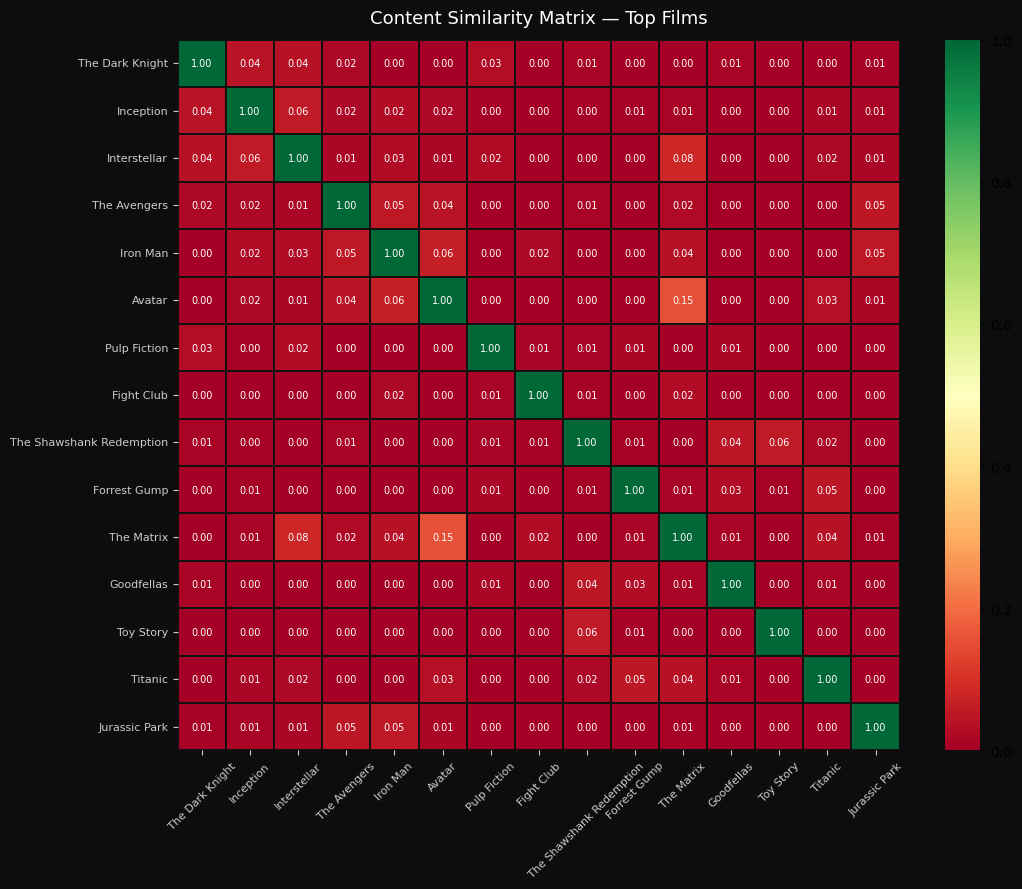

In [9]:
top_titles = [
    "The Dark Knight", "Inception", "Interstellar", "The Avengers",
    "Iron Man", "Avatar", "Pulp Fiction", "Fight Club",
    "The Shawshank Redemption", "Forrest Gump", "The Matrix",
    "Goodfellas", "Toy Story", "Titanic", "Jurassic Park"
]

# Get indices (skip any not found)
indices = []
labels  = []
for t in top_titles:
    key = t.lower()
    if key in title_index:
        indices.append(title_index[key])
        labels.append(t)

sub_matrix = sim_matrix[np.ix_(indices, indices)]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(sub_matrix, xticklabels=labels, yticklabels=labels,
            cmap="RdYlGn", vmin=0, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7}, ax=ax,
            linewidths=0.3, linecolor="#111")

ax.set_title("Content Similarity Matrix — Top Films", 
             fontsize=13, color="white", pad=12)
ax.tick_params(axis="x", rotation=45, labelsize=8, colors="#ccc")
ax.tick_params(axis="y", rotation=0,  labelsize=8, colors="#ccc")
fig.patch.set_facecolor("#0d0d0f")
ax.set_facecolor("#1e1e24")
plt.tight_layout()
plt.show()


## 7. Comparision

In [10]:
# Original: only used overview → TF-IDF
# Let's show the difference with a concrete example

from sklearn.feature_extraction.text import TfidfVectorizer as TFIDF
from sklearn.metrics.pairwise import cosine_similarity as cos

# Original approach (overview only)
overview_only = df["overview"].fillna("")
tfidf_orig = TFIDF(stop_words="english")
mat_orig = tfidf_orig.fit_transform(overview_only)
sim_orig = cos(mat_orig, mat_orig)

idx = title_index["the dark knight"]
scores_orig = sorted(enumerate(sim_orig[idx]), key=lambda x:x[1], reverse=True)
orig_top5 = [df["title"].iloc[i] for i,_ in scores_orig[1:6]]

# Improved approach (full soup)
scores_new = sorted(enumerate(sim_matrix[idx]), key=lambda x:x[1], reverse=True)
new_top5 = [df["title"].iloc[i] for i,_ in scores_new[1:6]]

comparison = pd.DataFrame({
    "Rank": range(1, 6),
    "Original (overview only)": orig_top5,
    "Improved (multi-feature)": new_top5
})
print("Comparison for 'The Dark Knight':")
display(comparison)


Comparison for 'The Dark Knight':


,Rank,Original (overview only),Improved (multi-feature)
0,1,The Dark Knight Rises,The Dark Knight Rises
1,2,Batman Returns,Batman Forever
2,3,"Batman: The Dark Knight Returns, Part 2",Batman Returns
3,4,Batman Forever,Batman Begins
4,5,Batman,"Batman: The Dark Knight Returns, Part 2"
